4 Tâches à accomplir  
 
Ce qui suit est une série de questions liées à divers aspects du traitement des données.  
 
4.1 Data Loading:  Jeu de données tabulaires ou séries temporelles 
1.  Charger le jeu de donnees sélectionné (par exemple, dans un DataFrame Pandas en 
utilisant des fonctions appropriees telles que ”pd.read_csv()” dans le cas de jeux de 
donnees tabulaires/séries temporelles). 

In [37]:
import pandas as pd

csv_path = './dataset/energydata_complete.csv'

df = pd.read_csv(csv_path)
print("Colonnes du dataset :", list(df.columns))
display(df.head())

# Signification des colonnes :
# - date : Date et heure de la mesure
# - Appliances : Consommation d’énergie (Wh) des appareils électroménagers
# - lights : Consommation d’énergie (Wh) de l’éclairage
# - T1 à T9 : Températures (°C) dans différentes pièces/zones (T1=salon, T2=cuisine, ...)
# - RH_1 à RH_9 : Humidité relative (%) dans les mêmes pièces/zones que T1 à T9
# - T_out : Température extérieure (°C)
# - Press_mm_hg : Pression atmosphérique (mm de mercure)
# - RH_out : Humidité relative extérieure (%)
# - Windspeed : Vitesse du vent (m/s)
# - Visibility : Visibilité (km)
# - Tdewpoint : Température du point de rosée (°C)
# - rv1, rv2 : Variables aléatoires (features artificielles, sans signification physique directe)
# Pour T1/RH_1 etc. :
#   - T1/RH_1 : Salon
#   - T2/RH_2 : Cuisine
#   - T3/RH_3 : Buanderie
#   - T4/RH_4 : Bureau
#   - T5/RH_5 : Salle de bain
#   - T6/RH_6 : Extérieur nord
#   - T7/RH_7 : Extérieur ouest
#   - T8/RH_8 : Garage
#   - T9/RH_9 : Chambre parentale

Colonnes du dataset : ['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


2.   Effectuer des tâches de pré-traitement des données telles que la gestion des 
valeurs manquantes, les conversions de types de données et le nettoyage des 
données.  

●  Vérifier les valeurs manquantes en utilisant ”df.isna()” et les traiter en les 
imputant ou en les supprimant. Assurez-vous d’expliquer les raisons derrière 
votre décision d’utiliser des techniques d'imputation ou de suppression pour 
traiter les données manquantes.

In [38]:
# Vérification et traitement des valeurs manquantes
missing = df.isna().sum()
print('Valeurs manquantes par colonne :')
print(missing) # Pas de valeur manquante 

# Suppression des lignes très incomplètes (plus de 10% de NaN)
df = df.dropna(thresh=int(0.9*len(df.columns)))

# Imputation par la moyenne pour les colonnes numériques restantes
for col in df.select_dtypes(include='number').columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mean())
        print(f"Imputation par la moyenne pour : {col}")

# Justification :
# On supprime les lignes très incomplètes pour éviter de fausser l'analyse, puis on impute par la moyenne pour conserver le maximum d'information sans introduire de biais important.

Valeurs manquantes par colonne :
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


In [39]:
print(df.isna().sum())

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


●  Convertir les types de données au besoin en utilisant ”df.astype()”.

In [40]:
print(df.dtypes) # Conversion possible : 'date' en datetime
df['date'] = pd.to_datetime(df['date'])

date               str
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object


In [41]:
print(df.dtypes)

date           datetime64[us]
Appliances              int64
lights                  int64
T1                    float64
RH_1                  float64
T2                    float64
RH_2                  float64
T3                    float64
RH_3                  float64
T4                    float64
RH_4                  float64
T5                    float64
RH_5                  float64
T6                    float64
RH_6                  float64
T7                    float64
RH_7                  float64
T8                    float64
RH_8                  float64
T9                    float64
RH_9                  float64
T_out                 float64
Press_mm_hg           float64
RH_out                float64
Windspeed             float64
Visibility            float64
Tdewpoint             float64
rv1                   float64
rv2                   float64
dtype: object


●  Nettoyer les données manquantes en supprimant les doublons à l’aide de ”df.drop_duplicates()” et en corrigeant les valeurs incohérentes. Vous devez indiquer quelle technique a  été appliquée. Si vous choisissez l’imputation, précisez quelle méthode spécifique vous trouvez la plus appropriée pour votre jeu de données et pourquoi?

In [42]:
# Suppression des doublons
avant = len(df)
df = df.drop_duplicates()
apres = len(df)
print(f"Nombre de doublons supprimés : {avant - apres}")

# Vérification de valeurs négatives sur les colonnes énergétiques
for col in df.select_dtypes(include='number').columns:
    if (df[col] < 0).any():
        print(f"Attention : valeurs négatives détectées dans {col}")

# Justification :
# On supprime les doublons pour éviter les biais et on signale les valeurs incohérentes pour garantir la qualité des données.

Nombre de doublons supprimés : 0
Attention : valeurs négatives détectées dans T6
Attention : valeurs négatives détectées dans T_out
Attention : valeurs négatives détectées dans Tdewpoint


●  Créer de nouvelles fonctionnalités ou transformer celles existantes pour améliorer la qualité et la pertinence des données (si possible). 

In [43]:
# Création de nouvelles fonctionnalités : différences de température intérieure/extérieure pour chaque pièce
T_pieces = [col for col in df.columns if col.startswith('T') and col != 'T_out']

for t_col in T_pieces:
    delta_col = f'delta_{t_col}_Tout'
    df[delta_col] = df[t_col] - df['T_out']
print(df[[col for col in df.columns if col.startswith('delta_T')]].head())

# Création d'une moyenne des températures intérieures
df['T_int_mean'] = df[T_pieces].mean(axis=1)
print(df[['T_int_mean'] + T_pieces].head())

# - delta_Tx_Tout : Différence entre la température de la pièce x (T1 à T9) et la température extérieure (T_out)
# - T_int_mean : Moyenne des températures intérieures (T1 à T9, hors T_out)

   delta_T1_Tout  delta_T2_Tout  delta_T3_Tout  delta_T4_Tout  delta_T5_Tout  \
0      13.290000      12.600000      13.190000      12.400000      10.566667   
1      13.406667      12.716667      13.306667      12.516667      10.683333   
2      13.523333      12.833333      13.423333      12.560000      10.800000   
3      13.640000      12.950000      13.540000      12.640000      10.916667   
4      13.756667      13.066667      13.656667      12.756667      11.066667   

   delta_T6_Tout  delta_T7_Tout  delta_T8_Tout  delta_T9_Tout  \
0       0.426667      10.600000      11.600000      10.433333   
1       0.350000      10.716667      11.716667      10.583333   
2       0.193333      10.833333      11.833333      10.633333   
3       0.183333      10.883333      11.850000      10.750000   
4       0.233333      11.066667      11.966667      10.866667   

   delta_Tdewpoint_Tout  
0             -1.300000  
1             -1.283333  
2             -1.266667  
3             -1.250000 

4.2 Analyse exploratoire des données (EDA) 
Profilage des données pour obtenir des informations sur leur distribution, leurs relations, leurs statistiques sommaires et les éventuels problèmes de qualité des données (données 
aberrantes).  
Dans cette partie, vous utiliserez Matplotlib, Seaborn pour créer une variété de graphiques, notamment :  
●  Des graphiques linéaires pour visualiser les tendances au fil du temps.

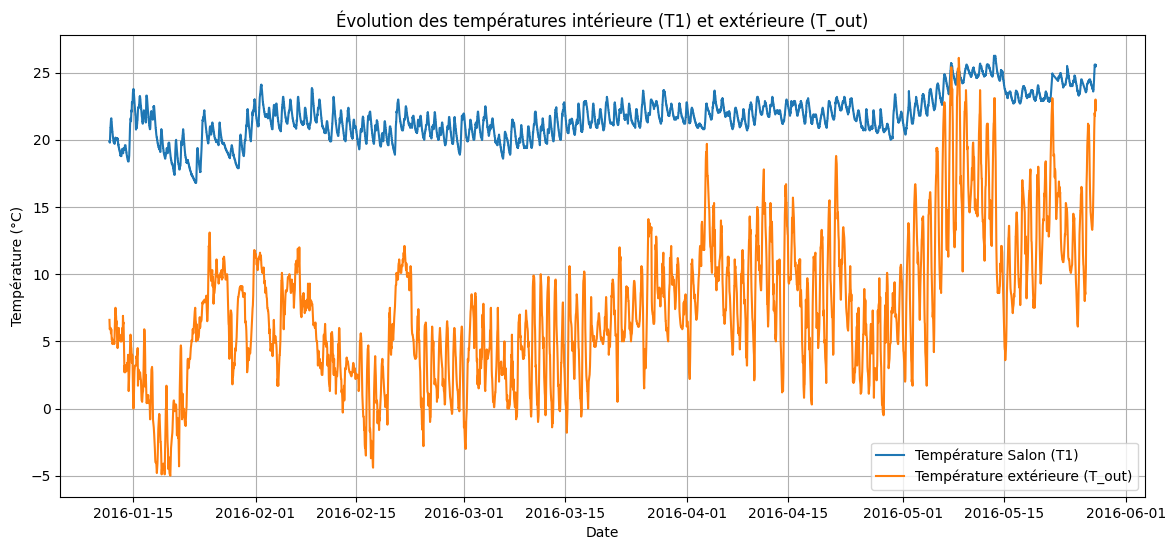

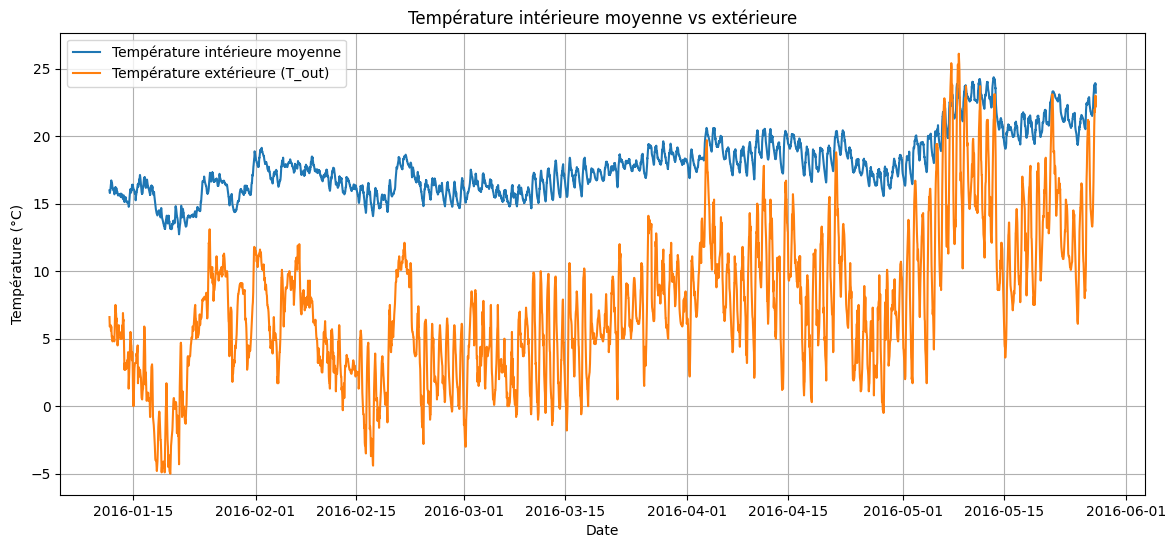

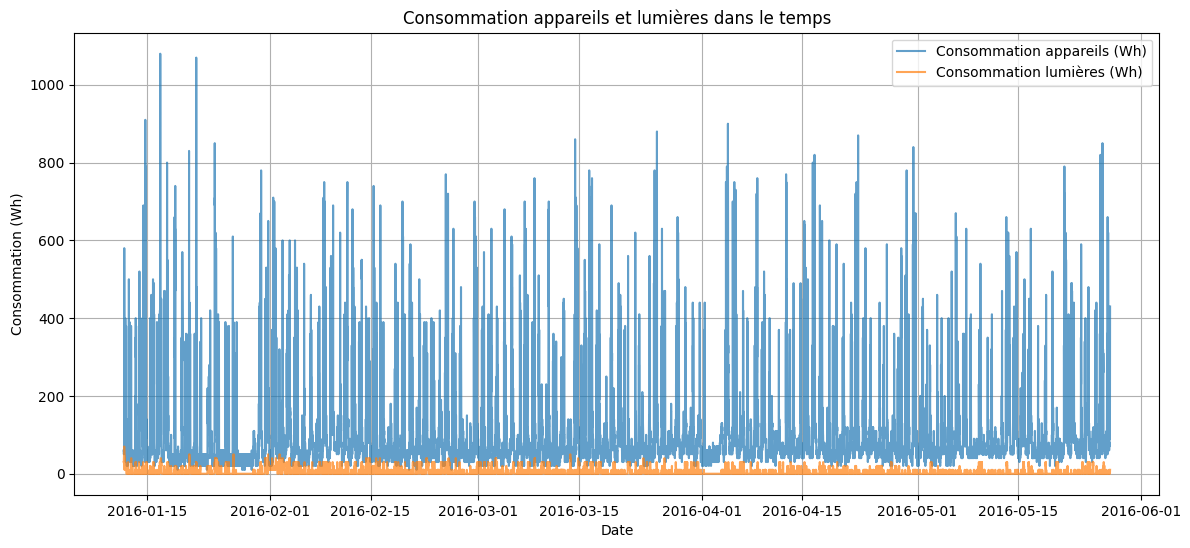

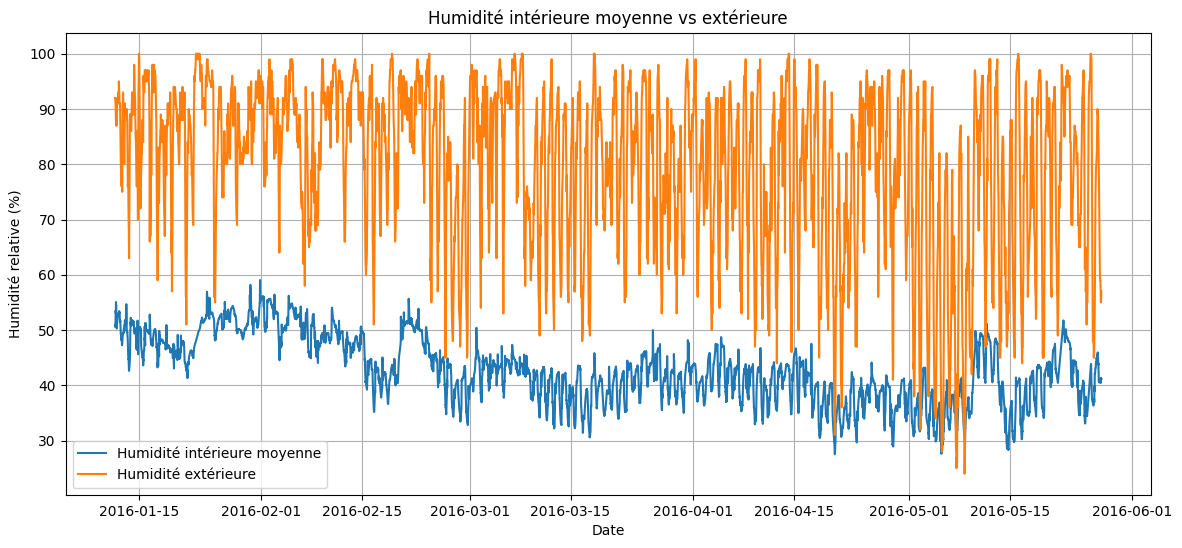

In [44]:
# Graphiques linéaires pour visualiser plusieurs statistiques temporelles
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
plt.plot(df['date'], df['T1'], label='Température Salon (T1)')
plt.plot(df['date'], df['T_out'], label='Température extérieure (T_out)')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.title('Évolution des températures intérieure (T1) et extérieure (T_out)')
plt.legend()
plt.grid(True)
plt.show()

# Température moyenne intérieure
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['T_int_mean'], label='Température intérieure moyenne')
plt.plot(df['date'], df['T_out'], label='Température extérieure (T_out)')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.title('Température intérieure moyenne vs extérieure')
plt.legend()
plt.grid(True)
plt.show()

# Consommation des appareils et des lumières
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['Appliances'], label='Consommation appareils (Wh)', alpha=0.7)
plt.plot(df['date'], df['lights'], label='Consommation lumières (Wh)', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Consommation (Wh)')
plt.title('Consommation appareils et lumières dans le temps')
plt.legend()
plt.grid(True)
plt.show()

# Humidité relative intérieure moyenne vs extérieure
RH_cols = [col for col in df.columns if col.startswith('RH_') and col != 'RH_out']
df['RH_int_mean'] = df[RH_cols].mean(axis=1)
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['RH_int_mean'], label='Humidité intérieure moyenne')
plt.plot(df['date'], df['RH_out'], label='Humidité extérieure')
plt.xlabel('Date')
plt.ylabel('Humidité relative (%)')
plt.title('Humidité intérieure moyenne vs extérieure')
plt.legend()
plt.grid(True)
plt.show()

●  Des graphiques de dispersion (scattering) pour identifier les relations entre les variables numériques. 

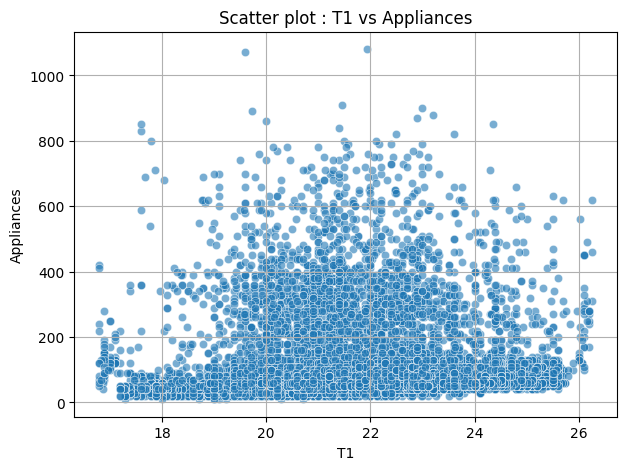

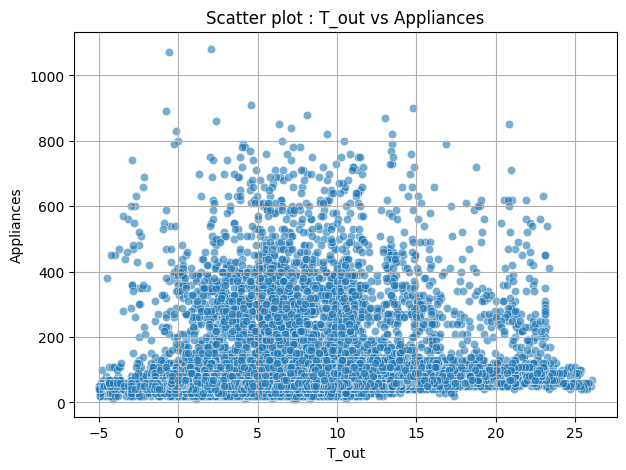

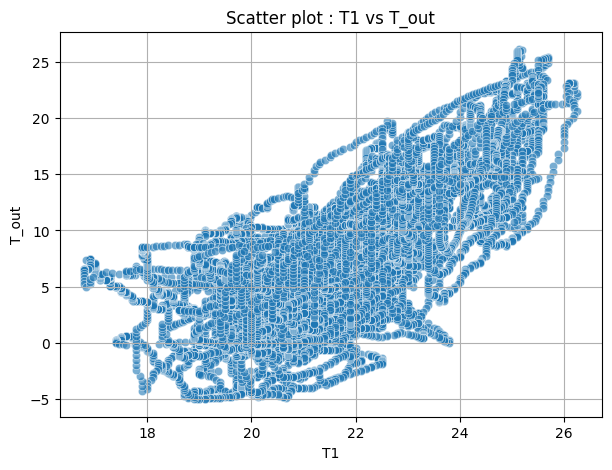

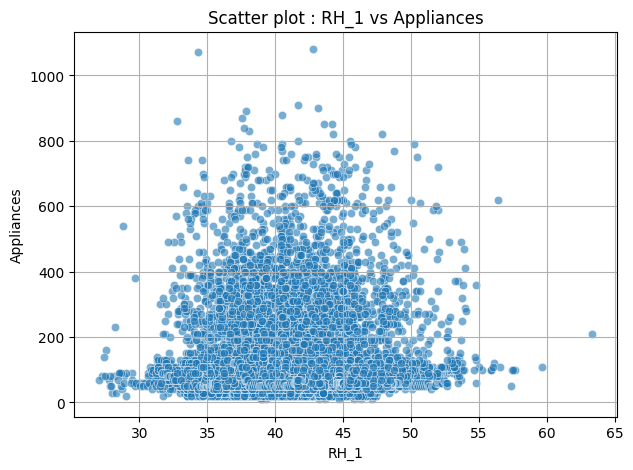

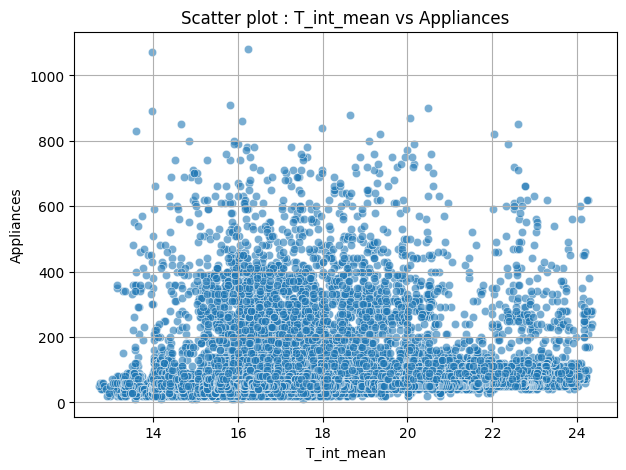

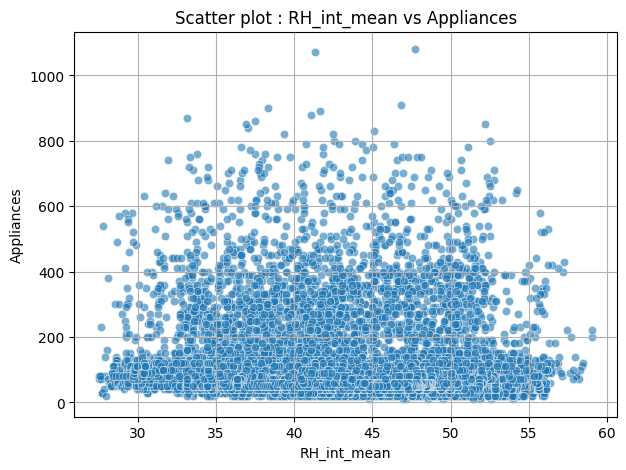

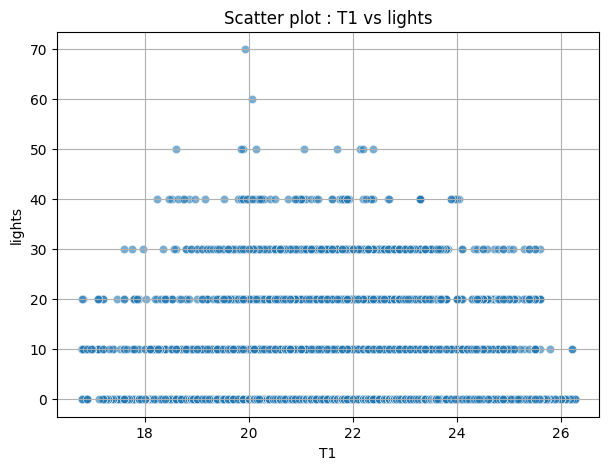

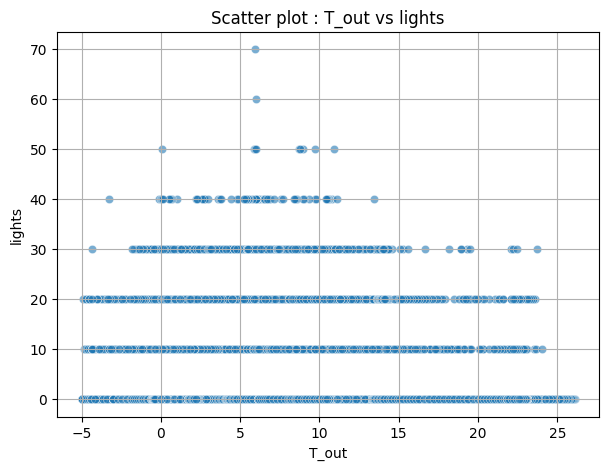

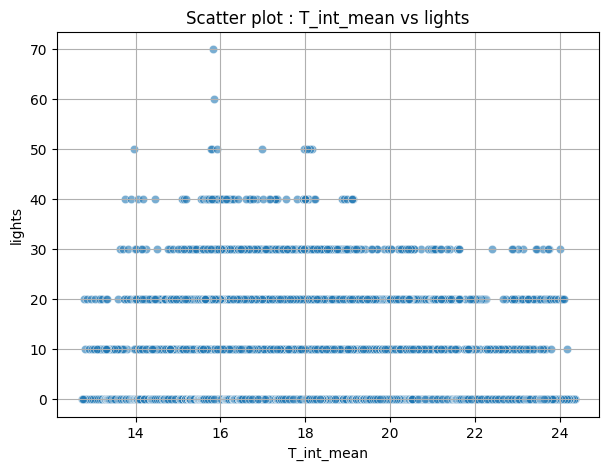

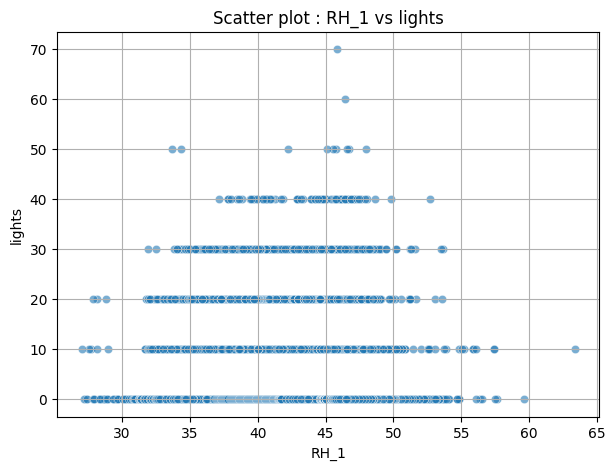

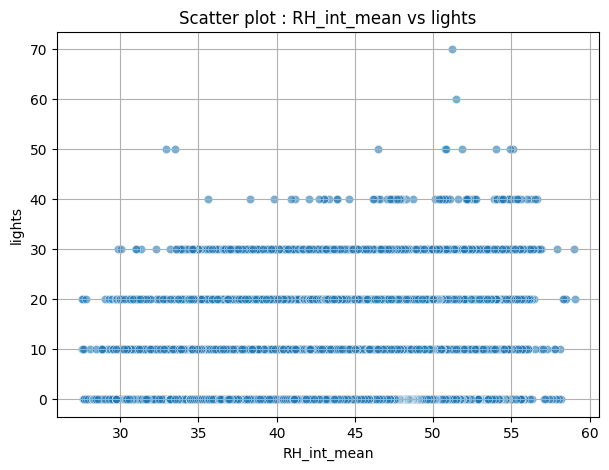

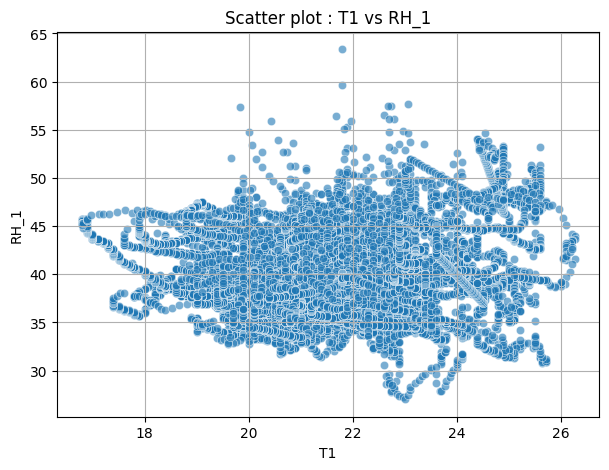

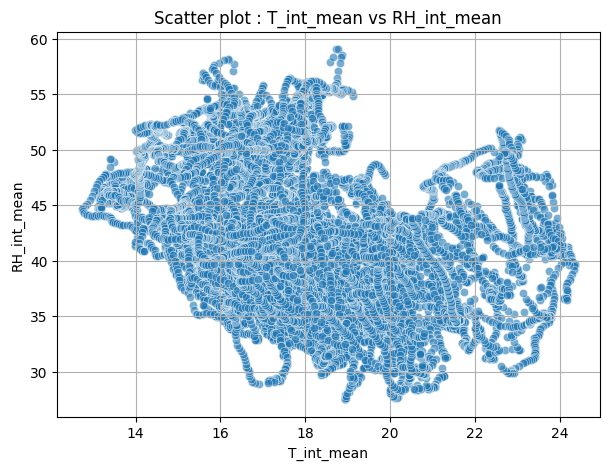

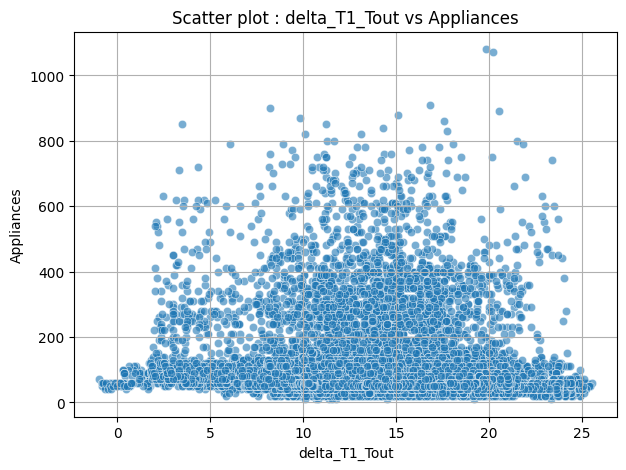

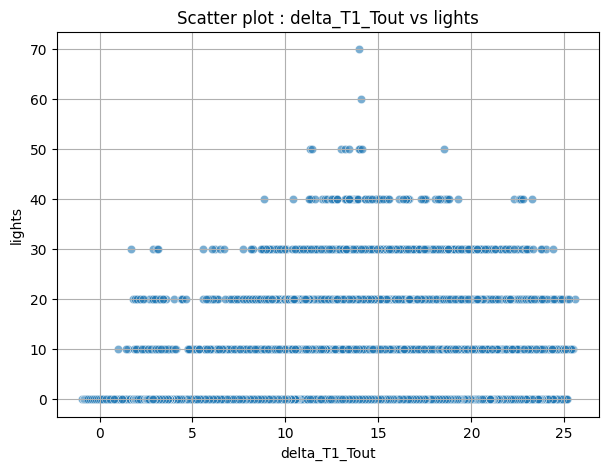

In [60]:
# Graphiques de dispersion pour explorer plus de relations entre variables énergétiques
import matplotlib.pyplot as plt
import seaborn as sns

scatter_pairs = [
    ('T1', 'Appliances'),
    ('T_out', 'Appliances'),
    ('T1', 'T_out'),
    ('RH_1', 'Appliances'),
    ('T_int_mean', 'Appliances'),
    ('RH_int_mean', 'Appliances'),
    ('T1', 'lights'),
    ('T_out', 'lights'),
    ('T_int_mean', 'lights'),
    ('RH_1', 'lights'),
    ('RH_int_mean', 'lights'),
    ('T1', 'RH_1'),
    ('T_int_mean', 'RH_int_mean'),
    ('delta_T1_Tout', 'Appliances'),
    ('delta_T1_Tout', 'lights'),
]

for x, y in scatter_pairs:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(7,5))
        sns.scatterplot(data=df, x=x, y=y, alpha=0.6)
        plt.title(f'Scatter plot : {x} vs {y}')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.grid(True)
        plt.show()

●  Des graphiques à barres pour comparer les données catégorielles.

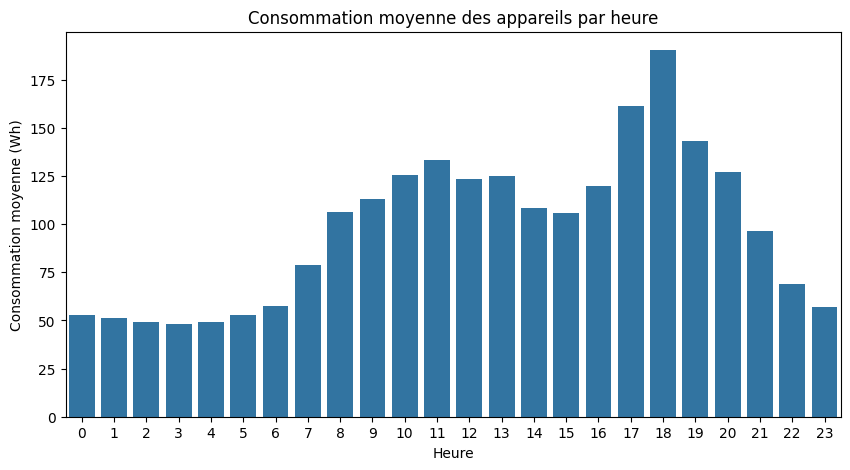

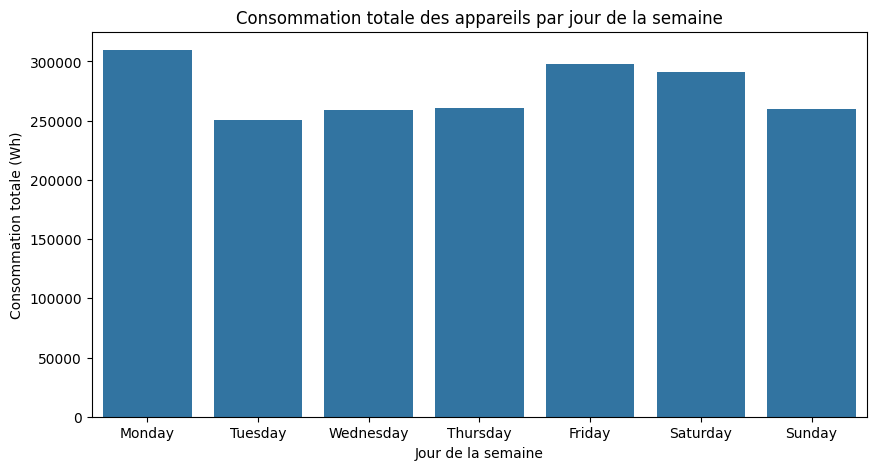

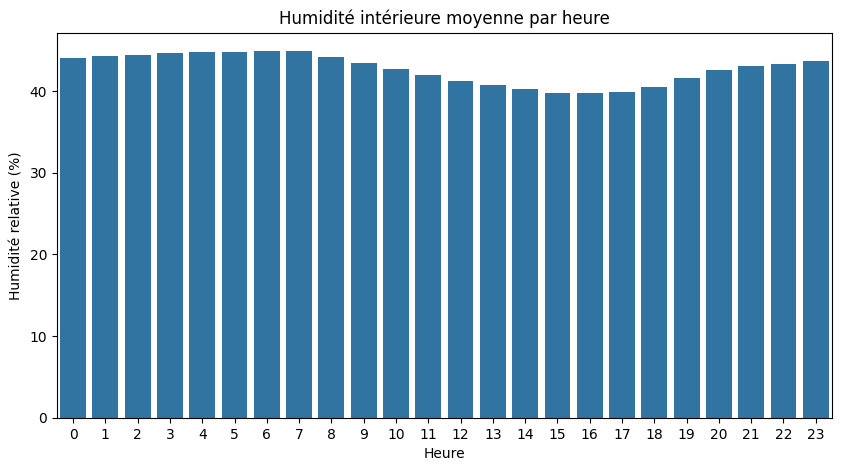

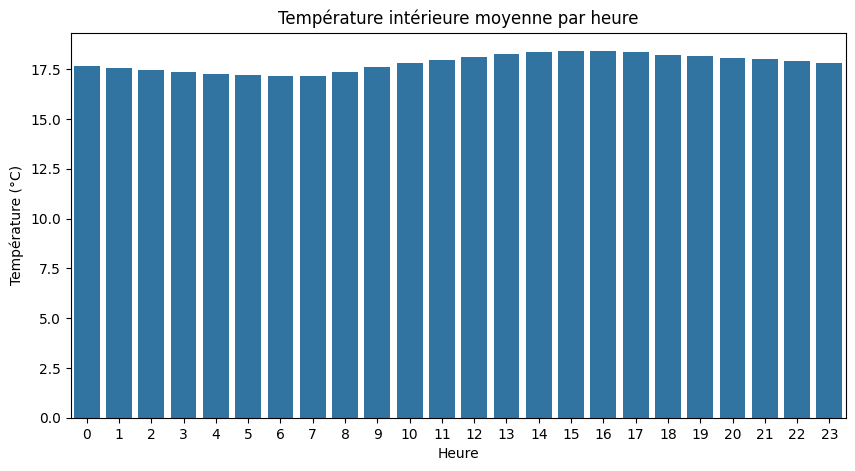

In [61]:
# Graphiques à barres pour explorer différentes statistiques catégorielles
import matplotlib.pyplot as plt
import seaborn as sns

# Consommation moyenne par heure
if 'hour' not in df.columns:
    df['hour'] = df['date'].dt.hour
hourly_mean = df.groupby('hour')['Appliances'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=hourly_mean.index, y=hourly_mean.values)
plt.title('Consommation moyenne des appareils par heure')
plt.xlabel('Heure')
plt.ylabel('Consommation moyenne (Wh)')
plt.show()

# Consommation totale par jour de la semaine
if 'weekday' not in df.columns:
    df['weekday'] = df['date'].dt.day_name()
weekday_sum = df.groupby('weekday')['Appliances'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sum.index, y=weekday_sum.values)
plt.title('Consommation totale des appareils par jour de la semaine')
plt.xlabel('Jour de la semaine')
plt.ylabel('Consommation totale (Wh)')
plt.show()

# Moyenne de l'humidité intérieure par heure
if 'RH_int_mean' not in df.columns:
    RH_cols = [col for col in df.columns if col.startswith('RH_') and col != 'RH_out']
    if RH_cols:
        df['RH_int_mean'] = df[RH_cols].mean(axis=1)
if 'RH_int_mean' in df.columns:
    hourly_rh = df.groupby('hour')['RH_int_mean'].mean()
    plt.figure(figsize=(10,5))
    sns.barplot(x=hourly_rh.index, y=hourly_rh.values)
    plt.title("Humidité intérieure moyenne par heure")
    plt.xlabel('Heure')
    plt.ylabel('Humidité relative (%)')
    plt.show()

# Moyenne de la température intérieure par heure
if 'T_int_mean' in df.columns:
    hourly_temp = df.groupby('hour')['T_int_mean'].mean()
    plt.figure(figsize=(10,5))
    sns.barplot(x=hourly_temp.index, y=hourly_temp.values)
    plt.title("Température intérieure moyenne par heure")
    plt.xlabel('Heure')
    plt.ylabel('Température (°C)')
    plt.show()

●  Des cartes thermiques pour montrer les corrélations entre les variables.

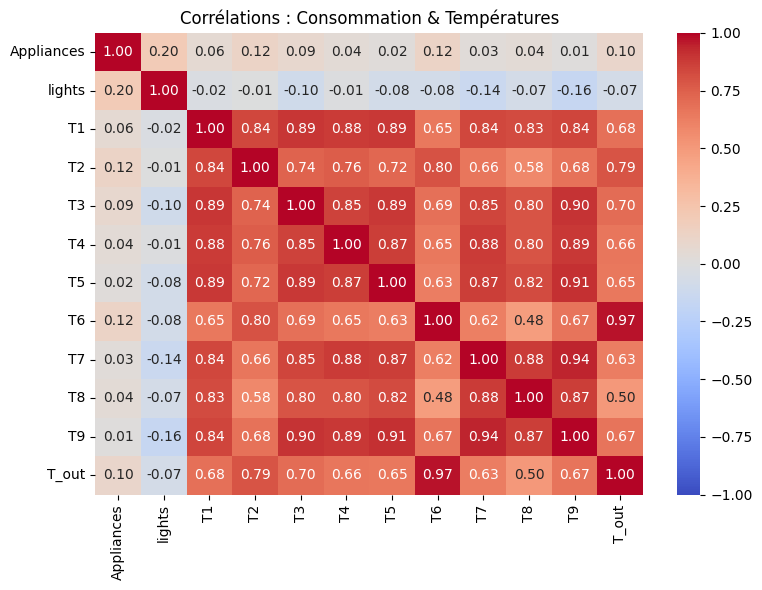

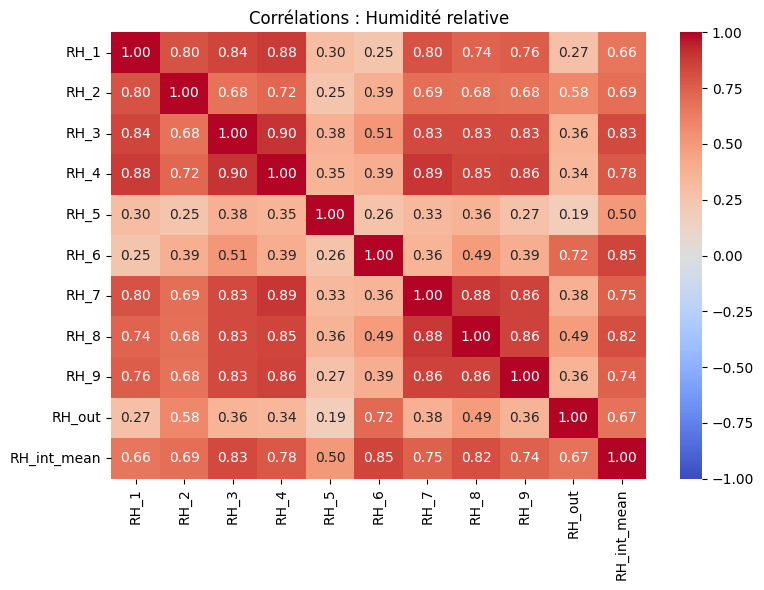

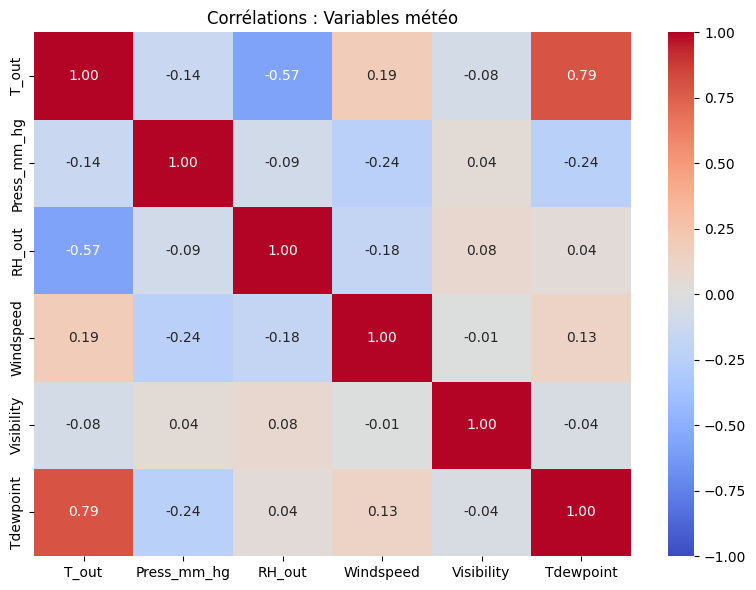

In [65]:
# Cartes thermiques fragmentées pour faciliter la lecture des corrélations
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.select_dtypes(include='number').corr()

# Fonction pour afficher une heatmap sur une sous-matrice
def plot_corr_heatmap(sub_corr, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(sub_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 1. Corrélations principales : consommation et températures
main_cols = ['Appliances', 'lights', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T_out']
plot_corr_heatmap(corr.loc[main_cols, main_cols], "Corrélations : Consommation & Températures")

# 2. Corrélations humidité
rh_cols = [col for col in corr.columns if col.startswith('RH_')]
if set(rh_cols).issubset(corr.columns):
    plot_corr_heatmap(corr.loc[rh_cols, rh_cols], "Corrélations : Humidité relative")

# 3. Corrélations météo
weather_cols = ['T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']
weather_cols = [col for col in weather_cols if col in corr.columns]
if weather_cols:
    plot_corr_heatmap(corr.loc[weather_cols, weather_cols], "Corrélations : Variables météo")


●  Créer des visualisations interactives à l’aide de bibliothèques comme Plotly pour améliorer l'expérience utilisateur (bonus).

In [48]:
# Visualisation interactive avec Plotly (bonus)
import plotly.express as px

fig = px.line(df, x='date', y=['T1', 'T_out'], title='Températures intérieure (T1) et extérieure (T_out) dans le temps')
fig.show()

In [49]:
# Installation forcée des dépendances nécessaires pour Plotly en notebook
import sys
!{sys.executable} -m pip install --upgrade plotly nbformat ipython
import plotly.express as px
import nbformat
import IPython

if 'release_date' in df.columns and 'total_sales' in df.columns:
    fig = px.scatter(df, x='release_date', y='total_sales', color='genre',
                     title='Ventes totales en fonction de la date de sortie',
                     labels={'release_date': 'Date de sortie', 'total_sales': 'Ventes totales (M)'})
    fig.show()
else:
    print("Colonnes nécessaires non trouvées pour la visualisation interactive.")

Colonnes nécessaires non trouvées pour la visualisation interactive.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ensuite, vous devez : 
1.  Calculer des statistiques sommaires (à l'aide de fonctions comme ”df.describe()”) pour comprendre les tendances centrales de jeu de données et les distributions en utilisant des histogrammes, des traces de densité (KDE) et d’autres visualisations pour visualiser la distribution des données. 

                             date    Appliances        lights            T1  \
count                       19735  19735.000000  19735.000000  19735.000000   
mean   2016-03-20 05:29:59.999999     97.694958      3.801875     21.686571   
min           2016-01-11 17:00:00     10.000000      0.000000     16.790000   
25%           2016-02-14 23:15:00     50.000000      0.000000     20.760000   
50%           2016-03-20 05:30:00     60.000000      0.000000     21.600000   
75%           2016-04-23 11:45:00    100.000000      0.000000     22.600000   
max           2016-05-27 18:00:00   1080.000000     70.000000     26.260000   
std                           NaN    102.524891      7.935988      1.606066   

               RH_1            T2          RH_2            T3          RH_3  \
count  19735.000000  19735.000000  19735.000000  19735.000000  19735.000000   
mean      40.259739     20.341219     40.420420     22.267611     39.242500   
min       27.023333     16.100000     20.463333    

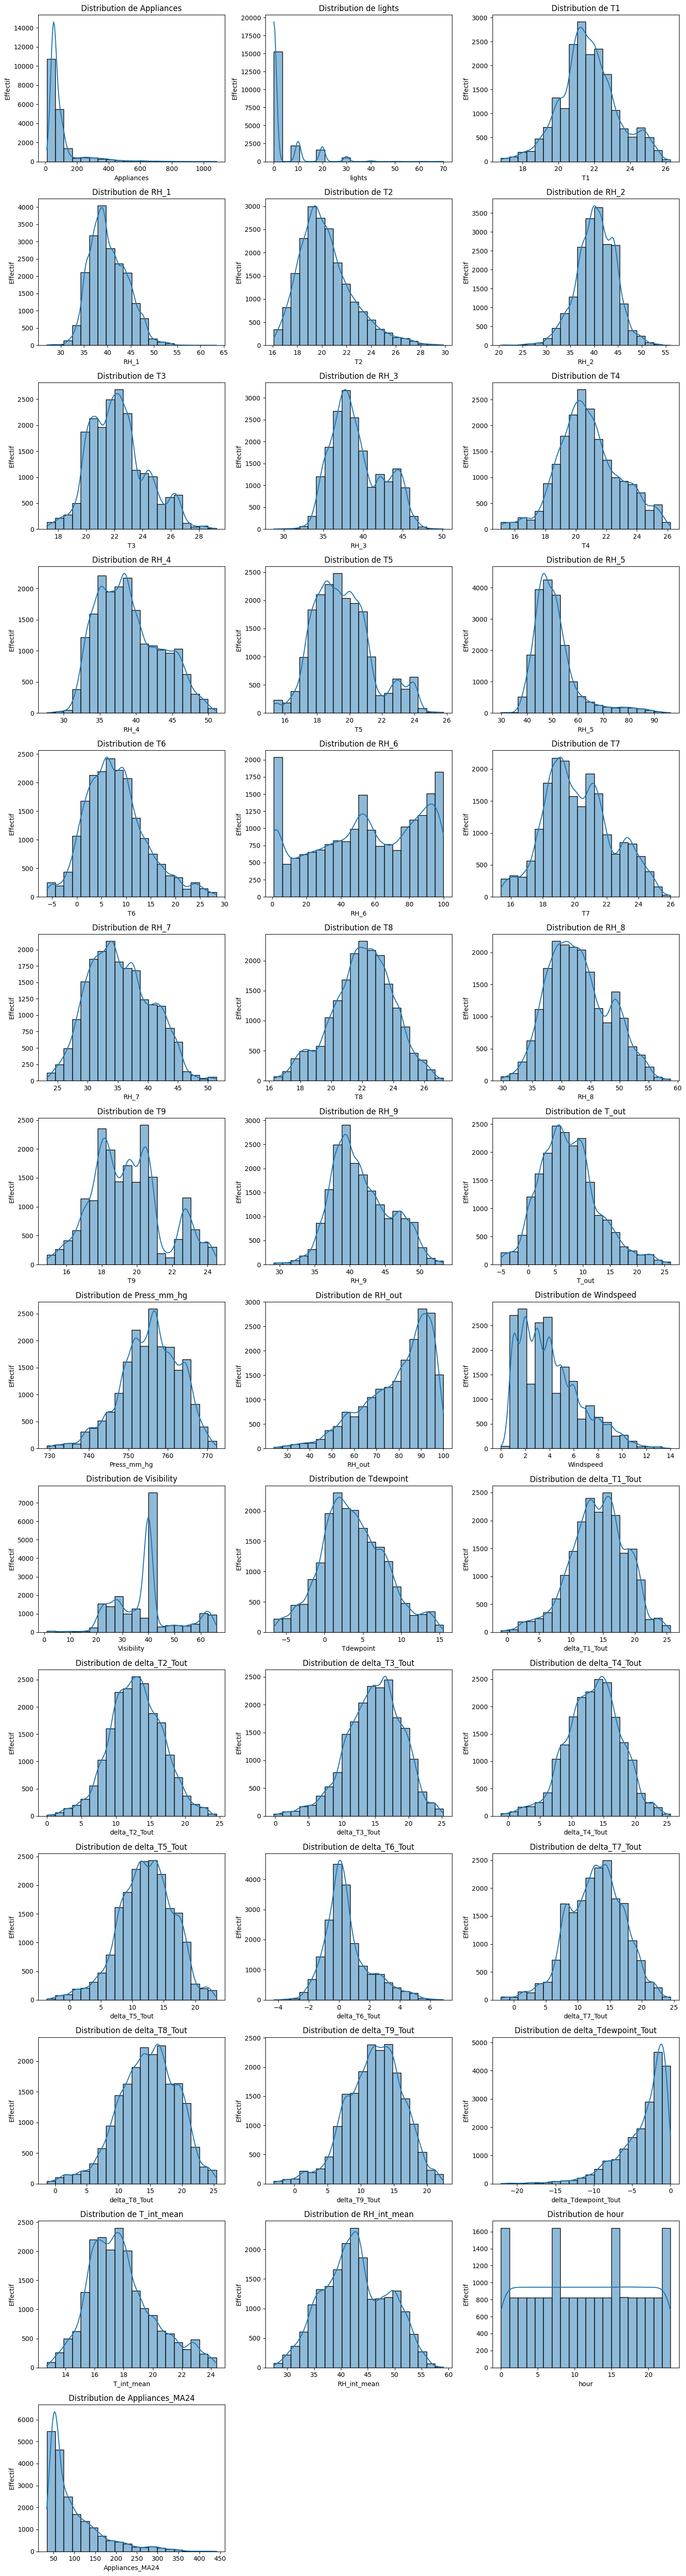

In [67]:
# Statistiques sommaires et histogrammes multiples
import matplotlib.pyplot as plt
import seaborn as sns

print(df.describe())

# Liste des colonnes numériques à visualiser (hors variables artificielles)
num_cols = [col for col in df.select_dtypes(include='number').columns if col not in ['rv1', 'rv2']]

# Affichage de plusieurs histogrammes sur une grille
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Effectif')

# Masquer les axes inutilisés
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

2.  Les valeurs aberrantes peuvent avoir un impact significatif sur l’analyse et les performances. Déterminer si les valeurs aberrantes sont des points de données valides ou des erreurs, et gérez-les en conséquence. Vous pouvez gérer les valeurs aberrantes en les visualisant à l’aide de boxplots et en décidant de les conserver ou 
de les supprimer. Les boxplot permettent de visualiser les quartiles, la médiane et les valeurs aberrantes dans les données.

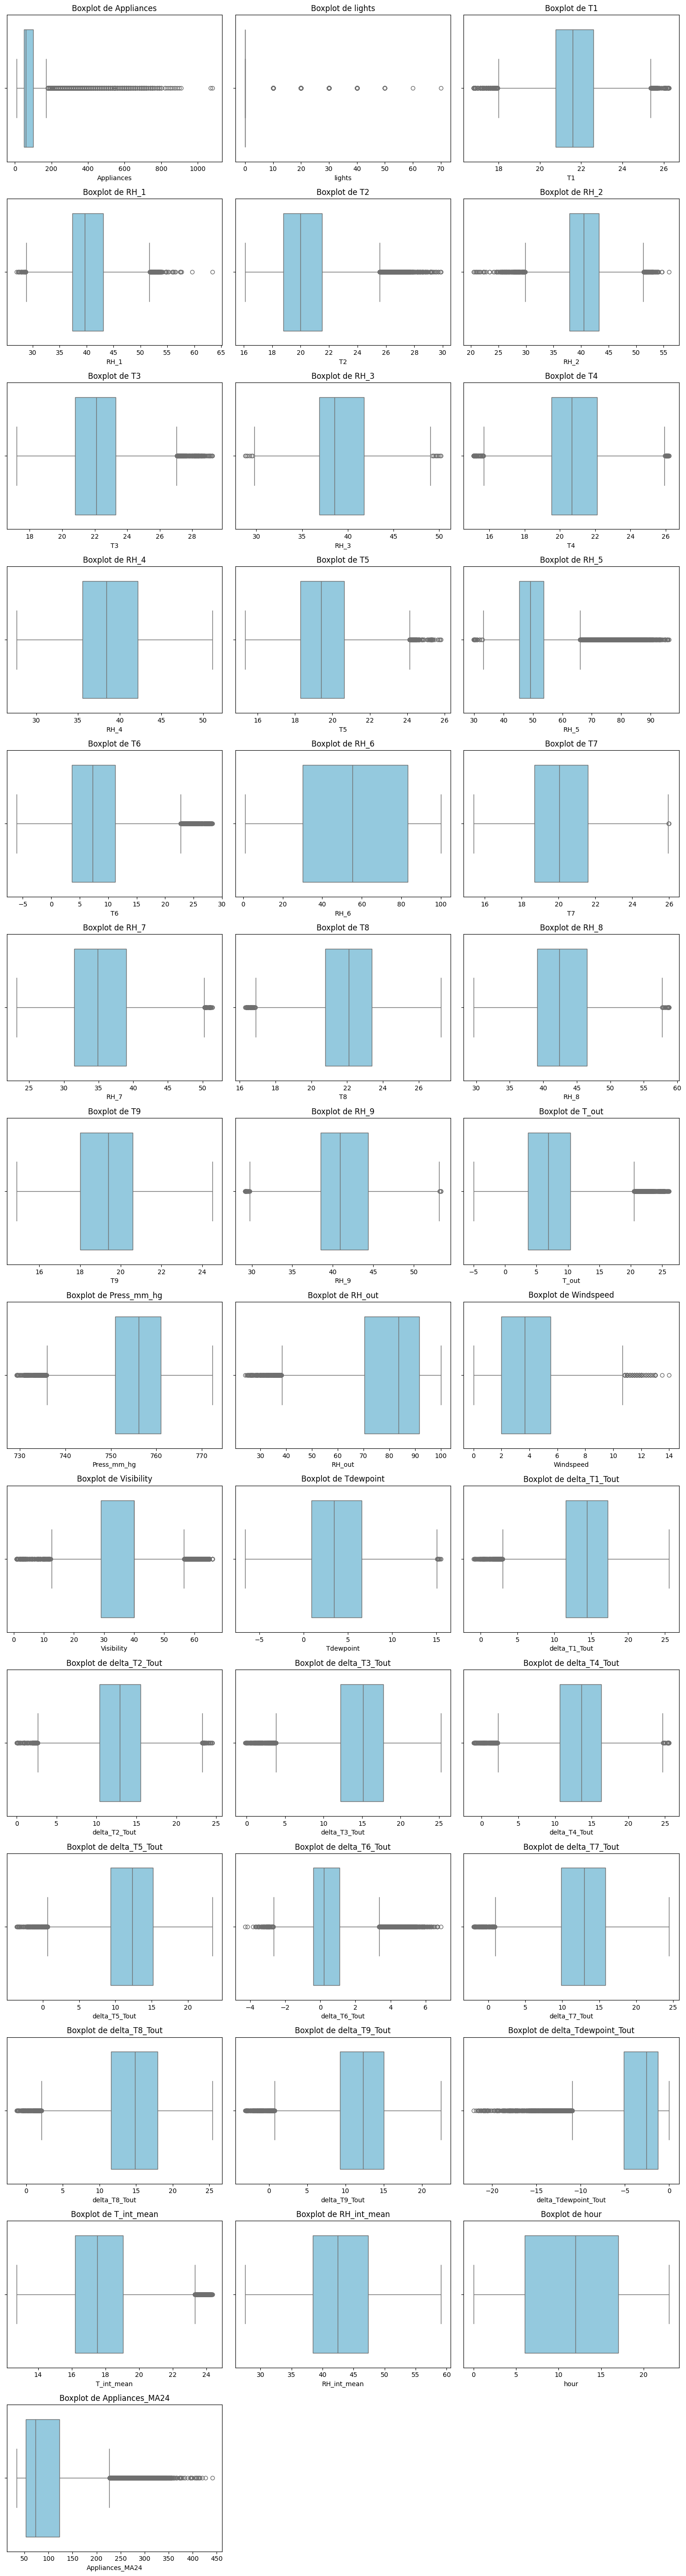

In [68]:
# Visualisation des valeurs aberrantes avec plusieurs boxplots
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des colonnes numériques à visualiser (hors variables artificielles)
num_cols = [col for col in df.select_dtypes(include='number').columns if col not in ['rv1', 'rv2']]

# Affichage de plusieurs boxplots sur une grille
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_xlabel(col)

# Masquer les axes inutilisés
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

3.  Calculer les matrices de corrélation et les tracer pour identifier les relations entre les variables numériques. 

In [69]:
# Corrélations : affichage sous forme de tableau et analyse automatique
import pandas as pd

corr = df.select_dtypes(include='number').corr()
print("Matrice de corrélation (extrait) :")
display(corr.round(2))

# Extraction des corrélations les plus fortes (hors diagonale)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Exclure la diagonale
top_corr = corr_pairs.drop_duplicates().sort_values(ascending=False).head(10)
print("\nTop 10 des corrélations (en valeur absolue) :")
print(top_corr)

# Analyse automatique des résultats
print("\nAnalyse des corrélations :")
for (var1, var2), value in top_corr.items():
    sign = 'positive' if corr.loc[var1, var2] > 0 else 'négative'
    print(f"- {var1} et {var2} : corrélation {sign} de {corr.loc[var1, var2]:.2f}")

Matrice de corrélation (extrait) :


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,delta_T5_Tout,delta_T6_Tout,delta_T7_Tout,delta_T8_Tout,delta_T9_Tout,delta_Tdewpoint_Tout,T_int_mean,RH_int_mean,hour,Appliances_MA24
Appliances,1.00,0.20,0.06,0.09,0.12,-0.06,0.09,0.04,0.04,0.02,...,-0.11,0.13,-0.11,-0.10,-0.12,-0.14,0.07,-0.06,0.22,0.52
lights,0.20,1.00,-0.02,0.11,-0.01,0.05,-0.10,0.13,-0.01,0.11,...,0.06,-0.06,0.03,0.06,0.02,0.07,-0.08,0.15,0.26,0.26
T1,0.06,-0.02,1.00,0.16,0.84,-0.00,0.89,-0.03,0.88,0.10,...,-0.46,0.24,-0.43,-0.43,-0.45,-0.38,0.90,-0.32,0.18,0.21
RH_1,0.09,0.11,0.16,1.00,0.27,0.80,0.25,0.84,0.11,0.88,...,-0.33,0.08,-0.41,-0.40,-0.37,0.27,0.30,0.66,0.02,0.13
T2,0.12,-0.01,0.84,0.27,1.00,-0.17,0.74,0.12,0.76,0.23,...,-0.66,0.45,-0.65,-0.66,-0.67,-0.54,0.85,-0.26,0.25,0.25
RH_2,-0.06,0.05,-0.00,0.80,-0.17,1.00,0.14,0.68,-0.05,0.72,...,0.01,-0.16,-0.07,-0.06,-0.02,0.59,0.09,0.69,-0.18,-0.08
T3,0.09,-0.10,0.89,0.25,0.74,0.14,1.00,-0.01,0.85,0.12,...,-0.48,0.31,-0.45,-0.47,-0.45,-0.31,0.92,-0.32,0.04,0.22
RH_3,0.04,0.13,-0.03,0.84,0.12,0.68,-0.01,1.00,-0.14,0.90,...,-0.17,-0.11,-0.27,-0.25,-0.24,0.34,0.02,0.83,-0.05,0.07
T4,0.04,-0.01,0.88,0.11,0.76,-0.05,0.85,-0.14,1.00,-0.05,...,-0.44,0.30,-0.39,-0.42,-0.41,-0.41,0.88,-0.44,0.09,0.12
RH_4,0.02,0.11,0.10,0.88,0.23,0.72,0.12,0.90,-0.05,1.00,...,-0.32,0.01,-0.43,-0.41,-0.39,0.32,0.20,0.78,-0.02,0.03



Top 10 des corrélations (en valeur absolue) :
delta_T9_Tout         delta_T7_Tout    0.987025
delta_Tdewpoint_Tout  RH_out           0.984872
delta_T5_Tout         delta_T9_Tout    0.981590
                      delta_T1_Tout    0.980685
delta_T7_Tout         delta_T8_Tout    0.978080
delta_T9_Tout         delta_T8_Tout    0.978036
delta_T1_Tout         delta_T3_Tout    0.977867
delta_T3_Tout         delta_T9_Tout    0.977621
delta_T5_Tout         delta_T3_Tout    0.977328
T6                    T_out            0.974787
dtype: float64

Analyse des corrélations :
- delta_T9_Tout et delta_T7_Tout : corrélation positive de 0.99
- delta_Tdewpoint_Tout et RH_out : corrélation positive de 0.98
- delta_T5_Tout et delta_T9_Tout : corrélation positive de 0.98
- delta_T5_Tout et delta_T1_Tout : corrélation positive de 0.98
- delta_T7_Tout et delta_T8_Tout : corrélation positive de 0.98
- delta_T9_Tout et delta_T8_Tout : corrélation positive de 0.98
- delta_T1_Tout et delta_T3_Tout : corrélation

4.  Utiliser des techniques appropriées de détection d’anomalies statistiques telles que Z-score pour identifier les valeurs aberrantes/anomalies dans l’ensemble de données. Visualiser et analyser les anomalies détectées. Quelles conclusions pouvez-vous en tirer? (bonus). 

In [ ]:
# Détection d'anomalies avec Z-score sur toutes les variables numériques et analyse
from scipy.stats import zscore
import numpy as np

# Calcul du Z-score pour toutes les colonnes numériques
z_scores_df = df.select_dtypes(include='number').apply(zscore)

# Seuil classique pour détecter les outliers
threshold = 3

# Détection des anomalies pour chaque variable
anomalies_dict = {}
for col in z_scores_df.columns:
    anomalies = df[np.abs(z_scores_df[col]) > threshold][col]
    if not anomalies.empty:
        anomalies_dict[col] = anomalies

# Affichage des anomalies détectées
for col, values in anomalies_dict.items():
    print(f"\nAnomalies détectées pour {col} (Z-score > {threshold}) :")
    print(values)

# Synthèse et analyse
print("\nAnalyse des anomalies détectées :")
if anomalies_dict:
    for col, values in anomalies_dict.items():
        print(f"- {len(values)} anomalies détectées pour {col}.")
else:
    print("Aucune anomalie significative détectée selon le critère du Z-score.")


Anomalies détectées pour Appliances (Z-score > 3) :
11       580
12       430
103      500
104      450
308      420
        ... 
19684    580
19685    660
19695    620
19733    420
19734    430
Name: Appliances, Length: 540, dtype: int64

Anomalies détectées pour lights (Z-score > 3) :
0        30
1        30
2        30
3        40
4        40
         ..
19326    30
19387    30
19392    30
19397    30
19607    30
Name: lights, Length: 647, dtype: int64

Anomalies détectées pour T1 (Z-score > 3) :
1717    16.823333
1722    16.856667
1723    16.856667
1724    16.790000
1725    16.790000
1726    16.790000
1727    16.790000
1728    16.790000
1729    16.790000
1730    16.790000
1731    16.790000
1732    16.790000
1733    16.790000
1734    16.823333
Name: T1, dtype: float64

Anomalies détectées pour RH_1 (Z-score > 3) :
13       52.726667
14       55.893333
15       53.893333
16       52.660000
17       53.660000
           ...    
19018    53.030000
19019    52.633333
19020    52.433333

4.3 Manipulation des données 
1.  Appliquer le regroupement (grouping) et l'agrégation pour calculer des statistiques sommaires pour des catégories spécifiques. Vous pouvez utiliser la fonction groupby() et des fonctions d'agrégation telles que sum(), mean(), et count() pour créer des tables de synthèse. 

In [72]:
# Regroupement et agrégation : statistiques sommaires par heure, jour et semaine
if 'date' in df.columns and 'Appliances' in df.columns:
    # Ajout des colonnes de temps si besoin
    if 'hour' not in df.columns:
        df['hour'] = df['date'].dt.hour
    if 'weekday' not in df.columns:
        df['weekday'] = df['date'].dt.day_name()
    if 'day' not in df.columns:
        df['day'] = df['date'].dt.date

    # Moyenne, somme et nombre de mesures par heure
    hourly_stats = df.groupby('hour')['Appliances'].agg(['mean', 'sum', 'count'])
    print('Statistiques par heure :')
    print(hourly_stats.head())

    # Moyenne, somme et nombre de mesures par jour
    daily_stats = df.groupby('day')['Appliances'].agg(['mean', 'sum', 'count'])
    print('\nStatistiques par jour :')
    print(daily_stats.head())

    # Moyenne, somme et nombre de mesures par jour de la semaine
    weekday_stats = df.groupby('weekday')['Appliances'].agg(['mean', 'sum', 'count'])
    print('\nStatistiques par jour de la semaine :')
    print(weekday_stats)

else:
    print("Colonnes nécessaires non trouvées pour le groupby.")

Statistiques par heure :
           mean    sum  count
hour                         
0     52.785888  43390    822
1     51.326034  42190    822
2     49.075426  40340    822
3     48.236010  39650    822
4     49.355231  40570    822

Statistiques par jour :
                  mean    sum  count
day                                 
2016-01-11  136.666667   5740     42
2016-01-12   85.694444  12340    144
2016-01-13   97.013889  13970    144
2016-01-14  151.388889  21800    144
2016-01-15  125.347222  18050    144

Statistiques par jour de la semaine :
                 mean     sum  count
weekday                             
Friday     104.622144  297650   2845
Monday     111.450684  309610   2778
Saturday   106.246345  290690   2736
Sunday      94.915936  259690   2736
Thursday    90.434028  260450   2880
Tuesday     87.125000  250920   2880
Wednesday   89.930556  259000   2880


2.  Effectuer des opérations de filtrage ( à l’aide de l’indexation booléenne basée sur des conditions spécifiques) et des opérations de tri pour extraire des sous-ensembles de données (afin d’obtenir des informations).

In [55]:
# Filtrage et tri : top 10 des pics de consommation
if 'date' in df.columns and 'Appliances' in df.columns:
    top10 = df[['date', 'Appliances']].sort_values(by='Appliances', ascending=False).head(10)
    print(top10)
else:
    print("Colonnes nécessaires non trouvées pour le filtrage/tri.")

                     date  Appliances
731   2016-01-16 18:50:00        1080
1451  2016-01-21 18:50:00        1070
432   2016-01-14 17:00:00         910
12088 2016-04-04 15:40:00         900
1452  2016-01-21 19:00:00         890
10668 2016-03-25 19:00:00         880
14693 2016-04-22 17:50:00         870
9031  2016-03-14 10:10:00         860
1821  2016-01-24 08:30:00         850
19582 2016-05-26 16:40:00         850


3.  Appliquer des techniques d’analyse de séries temporelles pour découvrir des tendances temporelles dans le cas d’un jeu de données de séries temporelles. 
Utiliser des moyennes mobiles (rolling averages) ou d’autres fonctions de séries temporelles pour lisser le bruit dans les données (bonus). 

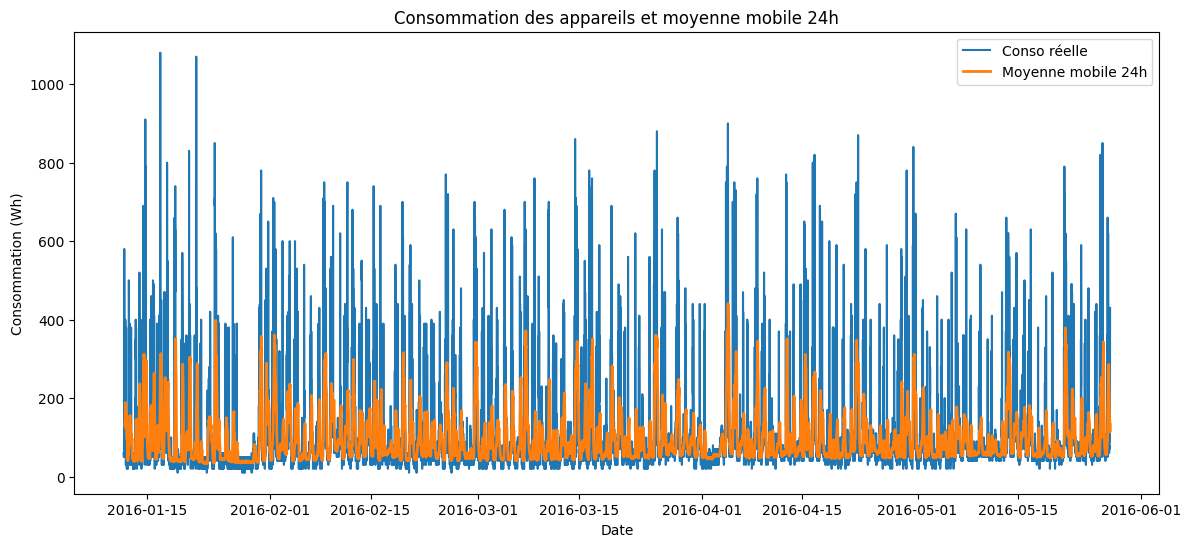

In [56]:
# Analyse de séries temporelles : moyenne mobile sur la consommation
if 'date' in df.columns and 'Appliances' in df.columns:
    df = df.sort_values('date')
    df['Appliances_MA24'] = df['Appliances'].rolling(window=24).mean()
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14,6))
    plt.plot(df['date'], df['Appliances'], label='Conso réelle')
    plt.plot(df['date'], df['Appliances_MA24'], label='Moyenne mobile 24h', linewidth=2)
    plt.title('Consommation des appareils et moyenne mobile 24h')
    plt.xlabel('Date')
    plt.ylabel('Consommation (Wh)')
    plt.legend()
    plt.show()
else:
    print("Colonnes nécessaires non trouvées pour l'analyse temporelle.")

4.4 Dérivation d’Informations  
1.  Assurez-vous d’avoir traité toutes les valeurs manquantes ou anomalies identifiées lors de l'examen du jeu de données.

In [57]:
# Vérification finale des valeurs manquantes ou anomalies
print('Valeurs manquantes par colonne :')
print(df.isna().sum())

for col in ['Appliances', 'T1', 'T_out']:
    if col in df.columns:
        print(f"{col} - min: {df[col].min()}, max: {df[col].max()}")

Valeurs manquantes par colonne :
date                     0
Appliances               0
lights                   0
T1                       0
RH_1                     0
T2                       0
RH_2                     0
T3                       0
RH_3                     0
T4                       0
RH_4                     0
T5                       0
RH_5                     0
T6                       0
RH_6                     0
T7                       0
RH_7                     0
T8                       0
RH_8                     0
T9                       0
RH_9                     0
T_out                    0
Press_mm_hg              0
RH_out                   0
Windspeed                0
Visibility               0
Tdewpoint                0
rv1                      0
rv2                      0
delta_T1_Tout            0
delta_T2_Tout            0
delta_T3_Tout            0
delta_T4_Tout            0
delta_T5_Tout            0
delta_T6_Tout            0
delta_T7_Tout         

2.  Effectuer une analyse pour identifier les corrélations au sein d’un jeu de données sélectionné. Dans le cas d’un ensemble de données de séries temporelles, une analyse plus approfondie est nécessaire pour identifier la saisonnalité et les tendances au fil du temps. 

In [58]:
# Analyse de corrélation approfondie
if 'Appliances' in df.columns:
    corr = df.corr(numeric_only=True)
    print(corr['Appliances'].sort_values(ascending=False))
else:
    print("Colonne 'Appliances' non trouvée pour la corrélation.")

Appliances              1.000000
Appliances_MA24         0.518518
hour                    0.216792
lights                  0.197278
delta_T6_Tout           0.126689
T2                      0.120073
T6                      0.117638
T_out                   0.099155
Windspeed               0.087122
RH_1                    0.086031
T3                      0.085060
T_int_mean              0.070351
T1                      0.055447
T4                      0.040281
T8                      0.039572
RH_3                    0.036292
T7                      0.025801
T5                      0.019760
RH_4                    0.016965
Tdewpoint               0.015353
T9                      0.010010
RH_5                    0.006955
Visibility              0.000230
rv1                    -0.011145
rv2                    -0.011145
Press_mm_hg            -0.034885
RH_9                   -0.051462
RH_7                   -0.055642
RH_int_mean            -0.060228
RH_2                   -0.060465
delta_T2_T

3.  Interpréter les résultats pour tirer des conclusions significatives. 

In [59]:
# Interprétation des résultats
print("--- Interprétation ---")
print("1. Les pics de consommation sont visibles dans le top 10.")
print("2. La consommation varie selon l'heure, voir le barplot par heure.")
print("3. Les températures intérieure et extérieure évoluent dans le temps, voir les courbes.")
print("4. Les corrélations fortes sont à observer dans la heatmap et la matrice.")
print("5. Les valeurs aberrantes sont détectées par le boxplot et le Z-score.")
print("6. Les tendances temporelles sont visibles avec la moyenne mobile.")

--- Interprétation ---
1. Les pics de consommation sont visibles dans le top 10.
2. La consommation varie selon l'heure, voir le barplot par heure.
3. Les températures intérieure et extérieure évoluent dans le temps, voir les courbes.
4. Les corrélations fortes sont à observer dans la heatmap et la matrice.
5. Les valeurs aberrantes sont détectées par le boxplot et le Z-score.
6. Les tendances temporelles sont visibles avec la moyenne mobile.
